# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "unique_norm_weights": None,
        "norm_unique_norm_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["unique_norm_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["norm_weights"], n_segments=n_segments
    )

    data_dict["norm_unique_norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_norm_weights"]
    )

    return data_dict

## Top ranked explanations

In [4]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    download_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
    skip_ranks_list=[-1],
):

    lw = 0.75

    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break
        if anomaly_rank + 1 in skip_ranks_list:
            print(f"Skipping rank {anomaly_rank + 1}.", end="\n")
            continue

        print(f"Explanation for anomaly rank {anomaly_rank + 1}", end="\r")

        specobjid = metadata_df.index[anomaly_rank]

        if download_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values

                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_rank]

        norm_weights_spec = norm_weights[anomaly_rank]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 0.4)
        y_ticks = np.arange(0, 0.41, 0.1)
        axs[1].set_yticks(y_ticks)

        if download_images is True:
            image_name = f"image_{specobjid}.jpeg"
        # Load the image
            img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

            # Create inset in top-right corner of axs[0]
            width_height_image = 1
            axins = inset_axes(
                axs[0],
                width=width_height_image,
                height=width_height_image,
                bbox_to_anchor=(1.01, 1.02),
                bbox_transform=axs[0].transAxes,
                loc="upper right",
            )

            # Show image in the inset
            axins.imshow(img)
            axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [5]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [6]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [8]:
score_name = "iforest"
bin_id = "bin_03"
n_segments = 343
n_clusters = 5

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_5_clusters_343_segments


## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

## Explanations

In [10]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

print(f"Loading XAI data from: {load_from}")

(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)

Loading XAI data from: /home/elom/phd/code/explanations/bin_03/iforest


## Order explanations according to score

In [11]:
scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/{score_name}/iforest_scores_bin_03_s128_e300_f100.csv",
    usecols=["specobjid", f"{score_name}_score"],
    index_col="specobjid",
).loc[specobjids_arr]

sorted_specobjids_arr = scores_df[f"{score_name}_score"].sort_values(
    ascending=False
).index.to_numpy()

# 1. Find the index mapping from specobjids_arr to sorted_specobjids_arr
indexer = pd.Index(specobjids_arr).get_indexer(sorted_specobjids_arr)

# 2. Reorder all three arrays simultaneously using the indexer
specobjids_arr = specobjids_arr[indexer]
anomalies_arr = anomalies_arr[indexer]
weights_arr = weights_arr[indexer]

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

scores_df.loc[specobjids_arr].head(5)

,iforest_score
specobjid,
969534273977608192,1.000000
1538002139001939968,0.988482
561847176611784704,0.985377
2829471472643237888,0.959367
2811439757043722240,0.935291


# K-means model
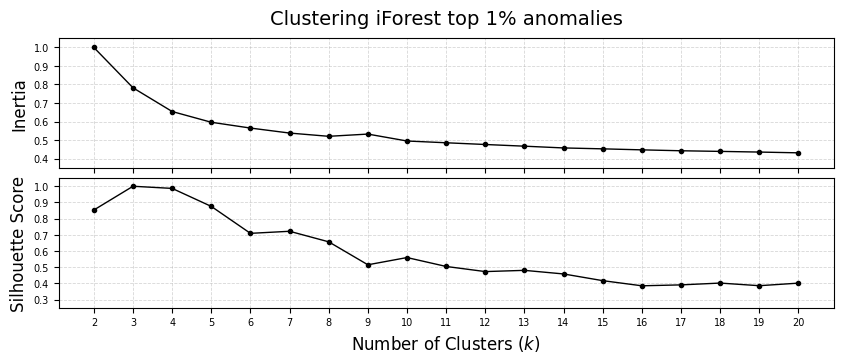

## Train data

In [12]:
X = weights_dict["norm_unique_norm_weights"]

## Train and save

In [13]:
# ```python
start_time = time.perf_counter()

kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)

end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# train time: 0.17 seconds
# [
# '/home/elom/phd/code/clustering/bin_03/iforest/kmeans_5_clusters_343_segments.joblib'
# ]
# ```

train time: 0.16 seconds


['/home/elom/phd/code/clustering/bin_03/iforest/kmeans_5_clusters_343_segments.joblib']

## Save metadata

In [14]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = cluster_labels

# append score, specobjids_arr is already sorted by score
cluster_meta_df[score_name] = scores_df[f"{score_name}_score"].loc[
    specobjids_arr
].copy()
cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")


# Clusters metadata

In [15]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict


weights_dict["centroids"] = kmeans_model.cluster_centers_

# 0;355
# 1;509
# 2;686
# 3;269

0;349
1;496
2;474
3;249
4;251


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
).loc[specobjids_arr]

# Line ratios

## Median line ratios

In [17]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.426871,0.15389,2.192326,1.649865,0.232222,1.370905,1.155083
1,3.371851,0.11195,3.237115,2.385488,0.219822,1.367044,1.374294
2,4.481943,0.402523,0.645638,0.877726,0.25199,1.257862,0.173775
3,3.681514,0.224364,1.050207,0.62225,0.243894,1.369542,0.68199
4,3.296409,0.53179,1.716806,1.262998,0.352166,1.412897,0.431135


## Percentiles per cluster

In [18]:
percentiles = np.arange(0.45, 0.60, 0.05)
ntile_labels = [f"{int(q * 100)}th" for q in percentiles]

# Clean column names once
clean_cols = [col.replace("_", " ") for col in SDSS_NEBULAR_LINES_RATIOS_NAMES]

blocks = []
clusters = sorted(cluster_meta_df["cluster"].dropna().unique())

for c_id in clusters:
    # 1. Create the header row for the current cluster
    header_df = pd.DataFrame([{"cluster": int(c_id), "ntile": ""}])

    # 2. Compute the quantiles for the current cluster
    mask = cluster_meta_df["cluster"] == c_id
    q_df = cluster_meta_df.loc[
        mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
    ].quantile(q=percentiles)

    # 3. Format the quantile dataframe
    q_df.columns = clean_cols
    q_df.insert(0, "cluster", "")  # Insert empty cluster col for data rows
    q_df.insert(1, "ntile", ntile_labels)  # Insert the ntile labels (45th, 50th, 55th)

    # 4. Append the header and data rows to our list
    blocks.append(header_df)
    blocks.append(q_df)

# Combine all blocks into a single DataFrame
result_df = pd.concat(blocks, ignore_index=True)

# Copy to clipboard (index=False because we don't need the default integer index)
result_df.to_clipboard(excel=True, index=False)
result_df

,cluster,ntile,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,45th,3.408002,0.142559,2.033437,1.524215,0.225815,1.362138,1.117785
2,,50th,3.426871,0.153890,2.192326,1.649865,0.232222,1.370905,1.155083
3,,55th,3.461251,0.159776,2.308829,1.813709,0.238817,1.379806,1.195902
4,1,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,,45th,3.336254,0.104240,3.041945,2.176314,0.209399,1.357014,1.314300
6,,50th,3.371851,0.111950,3.237115,2.385488,0.219822,1.367044,1.374294
7,,55th,3.412847,0.124388,3.360087,2.552504,0.228393,1.373954,1.435251
8,2,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,,45th,4.383398,0.389647,0.556121,0.778628,0.247013,1.243097,0.099017


# Clusters' XAI

## Centroid & Avg Spec

In [19]:
# lw = 0.75
# for label, centroid in enumerate(weights_dict["centroids"]):

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     centroid = clustering.expand_weights_per_segments(
#         centroid.reshape(1, -1),
#         wave_nm.size,
#         n_segments,
#     )
#     centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
#     avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

#     axs[0].plot(
#         wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
#     )
#     axs[1].legend()
#     # set limits
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label}",
#         fontsize=12,
#     )

#     plot_name = f"avg_spec_centroid_{label}"

#     save_to = f"{kmeans_model_dir}/avg_spec_centroids"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

## Centroid & Median Spec

In [20]:
# lw = 0.75
# for label, centroid in enumerate(weights_dict["centroids"]):

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     centroid = clustering.expand_weights_per_segments(
#         centroid.reshape(1, -1),
#         wave_nm.size,
#         n_segments,
#     )
#     centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
#     _spec = weights_dict["spectra_cluster_dict"][label]
#     med_spec = np.nanmedian(_spec, axis=0)

#     axs[0].plot(
#         wave_nm, med_spec, color="black", label="Median spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
#     )
#     axs[1].legend()
#     # set limits
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label}",
#         fontsize=12,
#     )

#     plot_name = f"median_spec_centroid_{label}"

#     save_to = f"{kmeans_model_dir}/median_spec_centroids"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

## Avg Spec & XAI

In [21]:
# lw = 0.75
# for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     spec = weights_dict["spectra_cluster_dict"][label_cluster]

#     avg_spectrum = spec.mean(axis=0)
#     avg_weights = weights.mean(axis=0)

#     axs[0].plot(
#         wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
#     )
#     axs[0].legend()
#     # weights
#     axs[1].plot(
#         wave_nm, avg_weights, color="black", label="Average explanation", linewidth=lw
#     )
#     axs[1].legend()
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label_cluster}",
#         fontsize=12,
#     )

#     plot_name = f"avg_spec_xai_{label_cluster}"

#     save_to = f"{kmeans_model_dir}/avg_spec_xai"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

## Median Spec & XAI

In [22]:
# lw = 0.75
# for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

#     fig, axs = plt.subplots(
#         nrows=2,
#         ncols=1,
#         figsize=(20, 7),
#         sharex=True,
#         sharey=False,
#     )

#     # set minor ticks on
#     for ax in axs.flatten():
#         ax.minorticks_on()

#     spec = weights_dict["spectra_cluster_dict"][label_cluster]

#     median_spec = np.nanmedian(spec, axis=0)
#     median_weights = np.nanmedian(weights, axis=0)

#     axs[0].plot(
#         wave_nm, median_spec, color="black", label="Median spectrum", linewidth=lw
#     )
#     axs[0].legend()
#    # weights
#    axs[1].plot(
#        wave_nm, median_weights, color="black", label="Median explanation",
#        linewidth=lw
#    )
#     axs[1].legend()
#     # set limits
#     axs[1].set_ylim(0, 0.31)
#     y_ticks = np.arange(0, 0.31, 0.1)
#     axs[1].set_yticks(y_ticks)
#     axs[1].set_xlabel(r"$\lambda$ [nm]")

#     fig.suptitle(
#         f"Cluster {label_cluster}",
#         fontsize=12,
#     )

#     plot_name = f"median_spec_xai_{label_cluster}"

#     save_to = f"{kmeans_model_dir}/median_spec_xai"
#     os.makedirs(save_to, exist_ok=True)

#     fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
#     fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
#     plt.clf()
#     plt.close(fig)

# Top ranked anomalies per cluster

In [23]:
# cluster_id = 0

# mask = cluster_meta_df["cluster"] == cluster_id

# metadata_df = cluster_meta_df.loc[mask].sort_values(
#     by=f"{score_name}", ascending=False
# )

# spectra = anomalies_arr[mask]
# norm_weights = weights_dict["norm_weights"][mask]

# plot_top_ranked_explanations(
#     cluster_id=cluster_id,
#     metadata_df=metadata_df,
#     spectra=spectra,
#     norm_weights=norm_weights,
#     wave=wave_nm,
#     kmeans_model_dir=kmeans_model_dir,
#     download_images=True,
#     n_top_ranked=-1,
#     max_norm_weights=False,
#     # skip_ranks_list=[57]
# )

## Check ranking

In [24]:
cluster_id = 3
mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]
metadata_df.loc[:, ["cluster", score_name]].head(10)
# scores_df.loc[mask].head(10)

,cluster,iforest
specobjid,,
315304777518966784,3,0.912673
1092189195696367616,3,0.884013
2430920226066425856,3,0.872757
540591142962489344,3,0.859446
2508590543529863168,3,0.832260
2997319900189452288,3,0.820630
520265569669244928,3,0.799944
306345137661831168,3,0.798663
1151881963641006080,3,0.796056


In [25]:
anomaly_rank = 0
cluster_id = 3

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

n_anomalies_in_cluster = metadata_df.shape[0]
print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

specobjid = metadata_df.index[anomaly_rank]
metadata_df.loc[specobjid, ["cluster", score_name]]

Number of anomalies in cluster 3: 249


cluster           3
iforest    0.912673
Name: 315304777518966784, dtype: object

In [26]:
# mask of oiii_to_oii = nan
cluster_id = 4
mask_cluster = cluster_meta_df["cluster"] == cluster_id
mask_oiii_to_oii_nan = cluster_meta_df.loc[mask_cluster]["oiii_to_oii"].isna()
n_nan = mask_oiii_to_oii_nan.sum()
n_total = mask_oiii_to_oii_nan.shape[0]
pct_valid = (n_total - n_nan) / n_total * 100
pct_nan = n_nan / n_total * 100
print(f"Cluster {cluster_id}: {n_nan} out of {n_total} have NaN oiii_to_oii values.\n")
print(f"\t{pct_nan:.0f}% have NaN oiii_to_oii values.")
print(f"\t{pct_valid:.0f}% have valid oiii_to_oii values.")
# specobjid = 3320337450726877184
# cluster_meta_df.loc[
#     specobjid,
#     [
#         'oii_3726_flux', 'oii_3729_flux', 'oiii_4959_flux', 'oiii_5007_flux',
#         'oiii_flux', 'oiii_to_oii'
#     ] + ['z', "cluster", score_name]
# ]

Cluster 4: 106 out of 251 have NaN oiii_to_oii values.

	42% have NaN oiii_to_oii values.
	58% have valid oiii_to_oii values.


# Cluster 0-3

## Data prep

In [27]:
# Cluster 0
weights_0 = weights_dict["weights_cluster_dict"][0]
med_weights_0 = np.nanmedian(weights_0, axis=0)
spec_0 = weights_dict["spectra_cluster_dict"][0]
med_spec_0 = np.nanmedian(spec_0, axis=0)
# Cluster 1
weights_1 = weights_dict["weights_cluster_dict"][1]
med_weights_1 = np.nanmedian(weights_1, axis=0)
spec_1 = weights_dict["spectra_cluster_dict"][1]
med_spec_1 = np.nanmedian(spec_1, axis=0)

# Cluster 2
weights_2 = weights_dict["weights_cluster_dict"][2]
med_weights_2 = np.nanmedian(weights_2, axis=0)
spec_2 = weights_dict["spectra_cluster_dict"][2]
med_spec_2 = np.nanmedian(spec_2, axis=0)

# Cluster 3
weights_3 = weights_dict["weights_cluster_dict"][3]
med_weights_3 = np.nanmedian(weights_3, axis=0)
spec_3 = weights_dict["spectra_cluster_dict"][3]
med_spec_3 = np.nanmedian(spec_3, axis=0)

## cluster 0 and 1

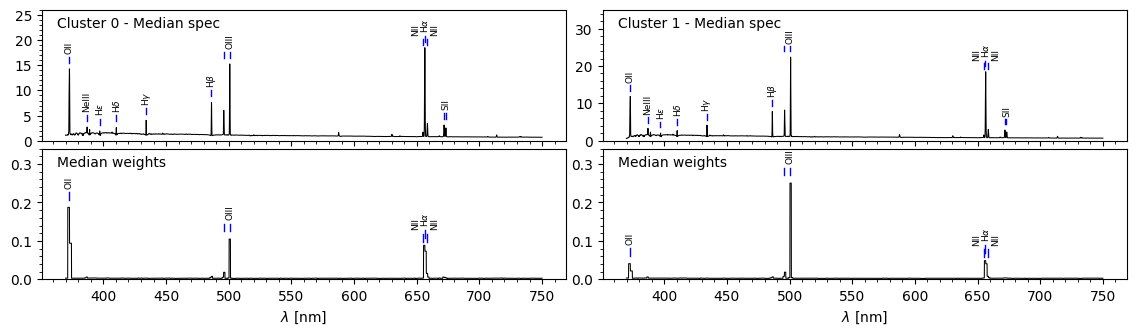

In [28]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# Cluster 0
axs[0, 0].plot(wave_nm, med_spec_0, color="black", linewidth=lw)

y_lims = (0, 26)
y_ticks = np.arange(0, 26, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
        'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 0], wave_nm, med_spec_0, **top_lines)

# weights
axs[1, 0].plot(wave_nm, med_weights_0, color="black", linewidth=lw)

bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'OIII', 'H_alpha'],
}
add_line_indicators(axs[1, 0], wave_nm, med_weights_0, **bottom_lines)

# ------------------------------------------------------------------
# Cluster 1
axs[0, 1].plot(wave_nm, med_spec_1, color="black", linewidth=lw)

y_lims = (0, 35)
y_ticks = np.arange(0, 35, 10)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.5,
    "indicator_height": 1.5,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
        'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 1], wave_nm, med_spec_1, **top_lines)

# weights
axs[1, 1].plot(wave_nm, med_weights_1, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'OIII', 'H_alpha'],
}
add_line_indicators(axs[1, 1], wave_nm, med_weights_1, **bottom_lines)
# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)

axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)
# wavelength
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text cluster 0
axs[0, 0].text(
    0.03, 0.95, 'Cluster 0 - Median spec', transform=axs[0, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[1, 0].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

# add text cluster 1
axs[0, 1].text(
    0.03, 0.95, 'Cluster 1 - Median spec', transform=axs[0, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1, 1].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
# fname = 'iforest_cluster_0_1'
# fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

## cluster 2 and 3

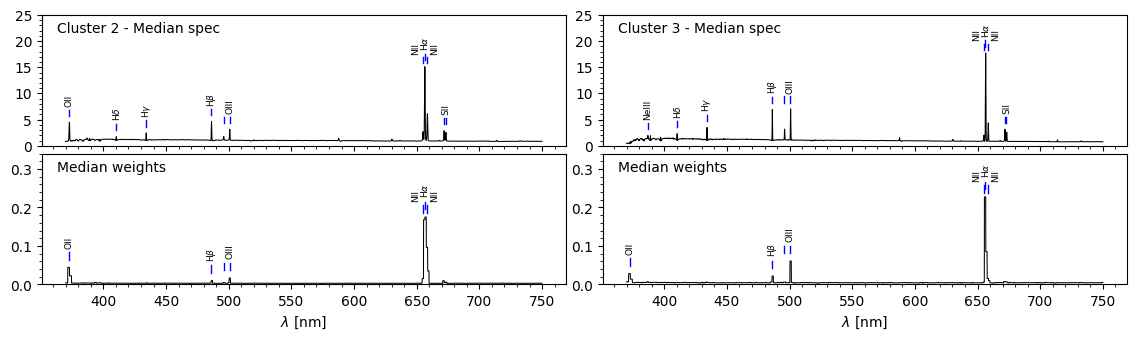

In [29]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 3.5),
    sharex=True,
    sharey=False,
)

# Cluster 2
axs[0, 0].plot(wave_nm, med_spec_2, color="black", linewidth=lw)

y_lims = (0, 25)
y_ticks = np.arange(0, 26, 5)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": [
        'OII', 'H_delta', 'H_gamma', 'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 0], wave_nm, med_spec_2, **top_lines)

# weights
axs[1, 0].plot(wave_nm, med_weights_2, color="black", linewidth=lw)

bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha'],
}
add_line_indicators(axs[1, 0], wave_nm, med_weights_2, **bottom_lines)

# ------------------------------------------------------------------
# Cluster 3
axs[0, 1].plot(wave_nm, med_spec_3, color="black", linewidth=lw)

y_lims = (0, 25)
y_ticks = np.arange(0, 26, 5)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

top_lines = {
    "indicator_starts": 1.2,
    "indicator_height": 1.2,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": [
        'NeIII', 'H_delta', 'H_gamma',
        'H_beta', 'OIII', 'H_alpha', 'SII'
    ],
}
add_line_indicators(axs[0, 1], wave_nm, med_spec_3, **top_lines)

# weights
axs[1, 1].plot(wave_nm, med_weights_3, color="black", linewidth=lw)
bottom_lines = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'H_beta', 'OIII', 'H_alpha'],
}
add_line_indicators(axs[1, 1], wave_nm, med_weights_3, **bottom_lines)
# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

axs[1, 0].set_ylim(y_lims)
axs[1, 0].set_yticks(y_ticks)

axs[1, 1].set_ylim(y_lims)
axs[1, 1].set_yticks(y_ticks)
# wavelength
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text cluster 2
axs[0, 0].text(
    0.03, 0.95, 'Cluster 2 - Median spec', transform=axs[0, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

axs[1, 0].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

# add text cluster 3
axs[0, 1].text(
    0.03, 0.95, 'Cluster 3 - Median spec', transform=axs[0, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1, 1].text(
    0.03, 0.95, 'Median weights', transform=axs[1, 1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
# fname = 'iforest_cluster_2_3'
# fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

## o to 3

1
3


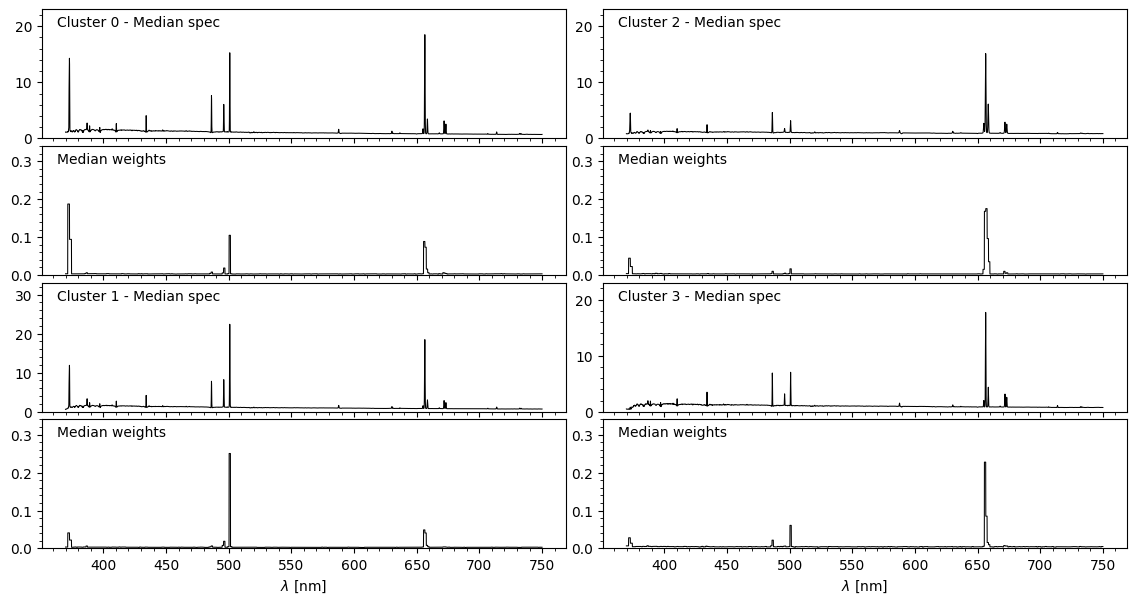

In [30]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=4, ncols=2,
    figsize=(14, 7),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 0
axs[0, 0].plot(wave_nm, med_spec_0, color="black", linewidth=lw)

y_lims = (0, 23)
y_ticks = np.arange(0, 23, 10)
axs[0, 0].set_ylim(y_lims)
axs[0, 0].set_yticks(y_ticks)

# weights
axs[1, 0].plot(wave_nm, med_weights_0, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 1
axs[2, 0].plot(wave_nm, med_spec_1, color="black", linewidth=lw)

y_lims = (0, 33)
y_ticks = np.arange(0, 31, 10)
axs[2, 0].set_ylim(y_lims)
axs[2, 0].set_yticks(y_ticks)

# weights
axs[3, 0].plot(wave_nm, med_weights_1, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 2
axs[0, 1].plot(wave_nm, med_spec_2, color="black", linewidth=lw)

y_lims = (0, 23)
y_ticks = np.arange(0, 23, 10)
axs[0, 1].set_ylim(y_lims)
axs[0, 1].set_yticks(y_ticks)

# weights
axs[1, 1].plot(wave_nm, med_weights_2, color="black", linewidth=lw)

# ------------------------------------------------------------------
# Cluster 3
axs[2, 1].plot(wave_nm, med_spec_3, color="black", linewidth=lw)

y_lims = (0, 23)
y_ticks = np.arange(0, 23, 10)
axs[2, 1].set_ylim(y_lims)
axs[2, 1].set_yticks(y_ticks)

# weights
axs[3, 1].plot(wave_nm, med_weights_3, color="black", linewidth=lw)

# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.34)
y_ticks = np.arange(0, 0.34, 0.1)

for i in range(0, 4, 2):
    print(i + 1)
    axs[i + 1, 0].set_ylim(y_lims)
    axs[i + 1, 0].set_yticks(y_ticks)
    axs[i + 1, 1].set_ylim(y_lims)
    axs[i + 1, 1].set_yticks(y_ticks)

# wavelength
axs[-1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[-1, 1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
for i in range(0, 2):

    axs[i * 2, 0].text(
        0.03, 0.95, f'Cluster {i} - Median spec',
        transform=axs[i * 2, 0].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )
    axs[i * 2 + 1, 0].text(
        # 0.03, 0.95, f'Cluster {i} - Median weights',
        0.03, 0.95, 'Median weights',
        transform=axs[i * 2 + 1, 0].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )

    axs[i * 2, 1].text(
        0.03, 0.95, f'Cluster {i + 2} - Median spec',
        transform=axs[i * 2, 1].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )
    axs[i * 2 + 1, 1].text(
        # 0.03, 0.95, f'Cluster {i + 2} - Median weights',
        0.03, 0.95, 'Median weights',
        transform=axs[i * 2 + 1, 1].transAxes,
        # fontsize=14,
        verticalalignment='top',
    )

plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# # save fig
# fname = 'iforest_clusters_0_to_3'
# fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# Cluster 4

## Data prep

In [31]:
# Cluster 4
weights_4 = weights_dict["weights_cluster_dict"][4]
med_weights_4 = np.nanmedian(weights_4, axis=0)
spec_4 = weights_dict["spectra_cluster_dict"][4]
med_spec_4 = np.nanmedian(spec_4, axis=0)


## Figure

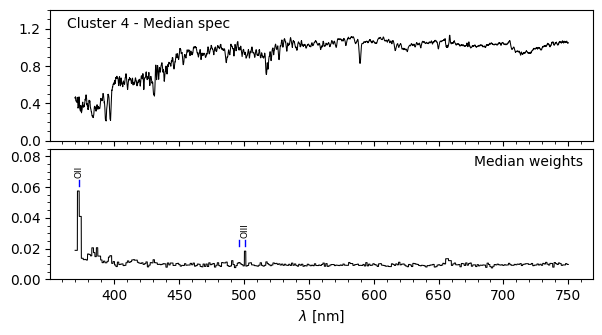

In [43]:
lw = 0.75

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=(7, 3.5),
    sharex=True,
    sharey=False,
)

# ------------------------------------------------------------------
# Cluster 4
axs[0].plot(wave_nm, med_spec_4, color="black", linewidth=lw)

y_lims = (0, 1.4)
y_ticks = [0, 0.4, 0.8, 1.2]
axs[0].set_ylim(y_lims)
axs[0].set_yticks(y_ticks)

# weights
axs[1].plot(wave_nm, med_weights_4, color="black", linewidth=lw)

# --------------------------------------------------------------------
# lim and ticks for explanation weights
y_lims = (0, 0.085)
y_ticks = [0, 0.02, 0.04, 0.06, 0.08]

axs[1].set_ylim(y_lims)
axs[1].set_yticks(y_ticks)
bottom_lines = {
    "indicator_starts": 0.0035,
    "indicator_height": 0.0035,
    "delta": 5,
    "fontsize": 6.5,
    "active_lines": ['OII', 'OIII'],
}
add_line_indicators(axs[1], wave_nm, med_weights_4, **bottom_lines)

# wavelength
axs[-1].set_xlabel(r"$\lambda$ [nm]")

# set minor ticks on
for ax in axs.flatten():
    ax.minorticks_on()

# add text
i = 0
axs[0].text(
    0.03, 0.95, 'Cluster 4 - Median spec',
    transform=axs[0].transAxes,
    # fontsize=14,
    verticalalignment='top',
)
axs[1].text(
    # 0.03, 0.95, 'Cluster 4 - Med weights',
    0.78, 0.95, 'Median weights',
    transform=axs[1].transAxes,
    # fontsize=14,
    verticalalignment='top',
)


plt.subplots_adjust(hspace=0.06, wspace=0.07)
plt.show()
# save fig
fname = 'iforest_clusters_4'
fig.savefig(f"{ch_6_dir}/{fname}_med.pdf", bbox_inches="tight")

# Appendix examples

## Cluster 0

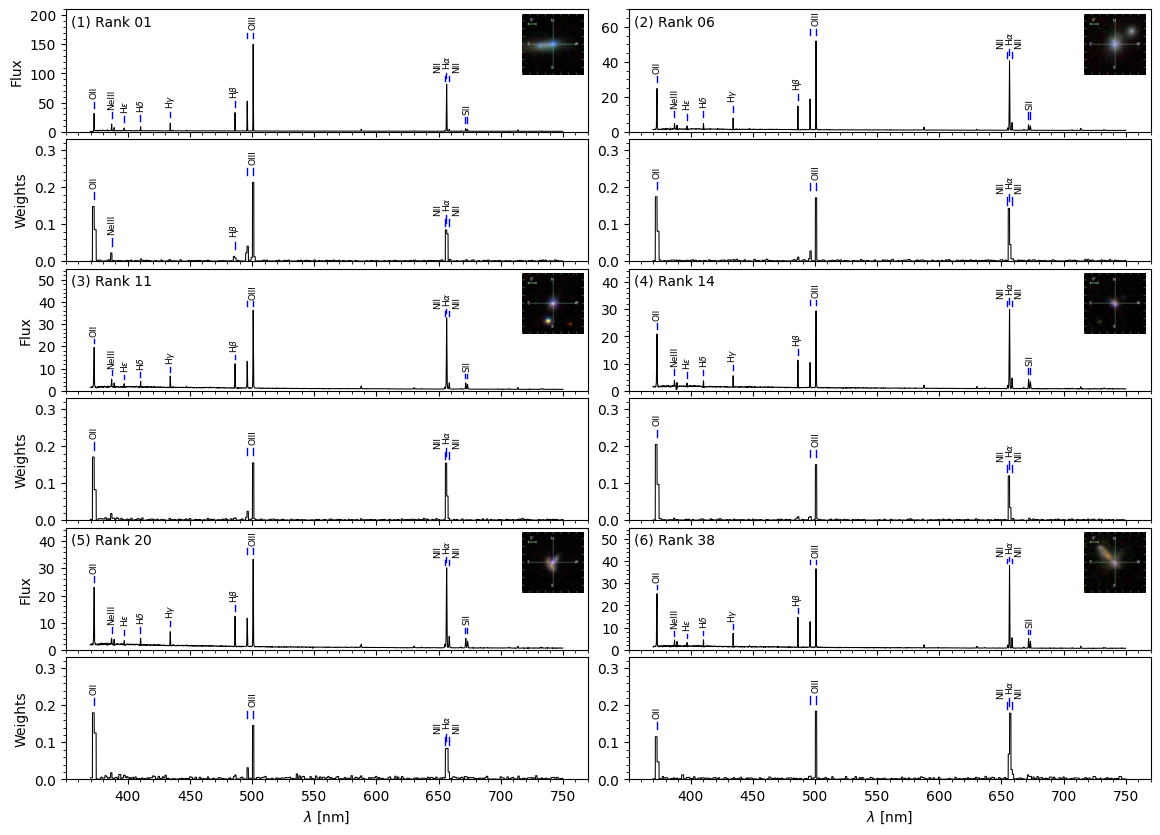

In [33]:
specobjids_dict = {
    1: 1538002139001939968,
    6: 1623656568488749056,
    11: 1798075945437915136,
    14: 951416797309986816,
    20: 2809136005657946112,
    38: 299601277875152896

}

cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

examples_spec_dict = {}
examples_weights_dict = {}
examples_img_dict = {}

for rank, specobjid in specobjids_dict.items():

    anomaly_rank = rank - 1
    assert specobjid == metadata_df.index[anomaly_rank], (
        f"specobjid mismatch: {specobjid} != {metadata_df.index[anomaly_rank]}"
    )

    spec = spectra[anomaly_rank]
    examples_spec_dict[rank] = spec

    norm_weights_spec = norm_weights[anomaly_rank]
    examples_weights_dict[rank] = norm_weights_spec

    # Load the image
    image_name = f"image_{specobjid}.jpeg"
    img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")
    examples_img_dict[rank] = img

fig, axs = plt.subplots(6, 2, sharex=True, figsize=(14, 10))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    1: {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 210),
        "yticks": range(0, 210, 50),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    6: {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 70),
        "yticks": range(0, 70, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    11: {
        "prefix": "(3)",
        "r": 2,
        "c": 0,
        "ylim": (0, 55),
        "yticks": range(0, 55, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    14: {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 45),
        "yticks": range(0, 45, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    20: {
        "prefix": "(5)",
        "r": 4,
        "c": 0,
        "ylim": (0, 45),
        "yticks": range(0, 45, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    38: {
        "prefix": "(6)",
        "r": 4,
        "c": 1,
        "ylim": (0, 55),
        "yticks": range(0, 55, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    1: {
        "top": {
            "indicator_starts": 10,
            "indicator_height": 10,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'NeIII', 'H_beta', 'OIII', 'H_alpha'],
        },
    },
    6: {
        "top": {
            "indicator_starts": 3.5,
            "indicator_height": 3.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha'],
        },
    },
    11: {
        "top": {
            "indicator_starts": 2,
            "indicator_height": 2,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha'],
        },
    },
    14: {
        "top": {
            "indicator_starts": 2,
            "indicator_height": 2,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha'],
        },
    },
    20: {
        "top": {
            "indicator_starts": 2,
            "indicator_height": 2,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha'],
        },
    },
    38: {
        "top": {
            "indicator_starts": 2,
            "indicator_height": 2,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma', 'H_beta',
                'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha'],
        },
    },

}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for rank, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(rank, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        examples_spec_dict[rank],
        examples_img_dict[rank],
        add_image=True,
        lw=line_width_spec,
    )
    name = f"Rank {rank:02d}"
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, examples_spec_dict[rank], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, examples_weights_dict[rank],
        lw=line_width_xai
    )
    # # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 0.33)
    axs[r + 1, c].set_yticks([0, 0.1, 0.2, 0.3])
    axs[r + 1, c].minorticks_on()

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, examples_weights_dict[rank], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[-1, col].set_xlim(350, 770)
    axs[-1, col].set_xticks(wave_ticks)
    axs[-1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# # Save figure
# fig.savefig(
#     f"{ch_6_dir}/iforest_cluster_{cluster_id}_examples.pdf", bbox_inches="tight"
# )

## Cluster 1

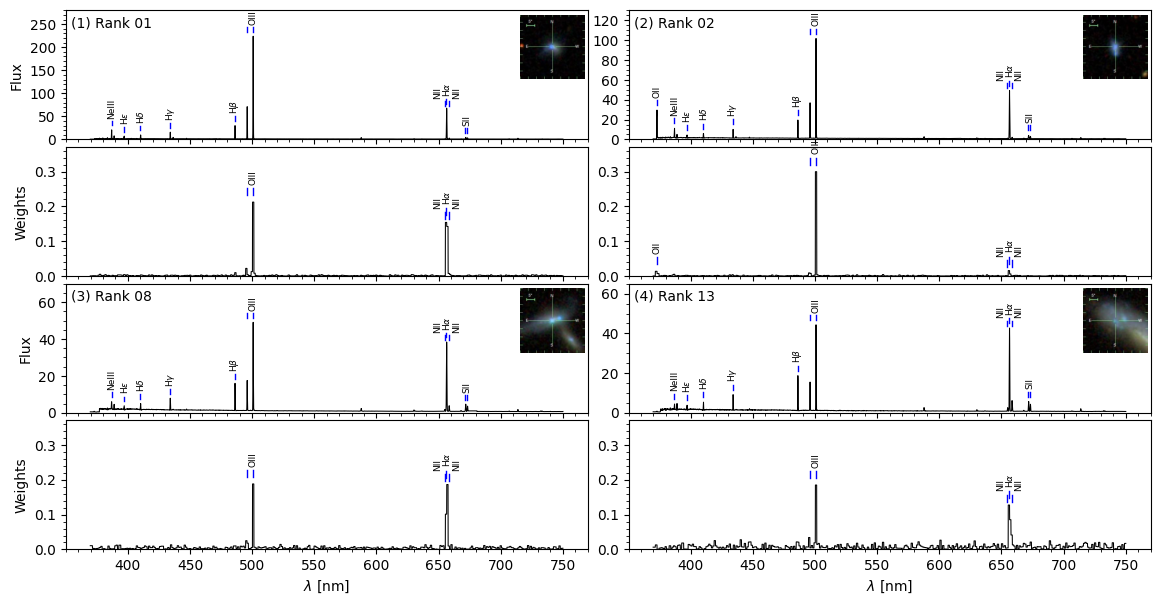

In [34]:
specobjids_dict = {
    1: 969534273977608192,
    2: 561847176611784704,
    8: 546145599485929472,
    13: 749873288389355520
}

cluster_id = 1
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)
spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

examples_spec_dict = {}
examples_weights_dict = {}
examples_img_dict = {}

for rank, specobjid in specobjids_dict.items():

    anomaly_rank = rank - 1
    assert specobjid == metadata_df.index[anomaly_rank], (
        f"specobjid mismatch: {specobjid} != {metadata_df.index[anomaly_rank]}"
    )

    spec = spectra[anomaly_rank]
    examples_spec_dict[rank] = spec

    norm_weights_spec = norm_weights[anomaly_rank]
    examples_weights_dict[rank] = norm_weights_spec

    # Load the image
    image_name = f"image_{specobjid}.jpeg"
    img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")
    examples_img_dict[rank] = img

fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
line_width_spec = 0.75
line_width_xai = 0.75
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    1: {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 280),
        "yticks": range(0, 280, 50),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    2: {
        "prefix": "(2)",
        "r": 0,
        "c": 1,
        "ylim": (0, 130),
        "yticks": range(0, 130, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    8: {
        "prefix": "(3)",
        "r": 2,
        "c": 0,
        "ylim": (0, 70),
        "yticks": range(0, 70, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    13: {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 65),
        "yticks": range(0, 65, 20),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    1: {
        "top": {
            "indicator_starts": 10,
            "indicator_height": 10,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
                'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OIII', 'H_alpha'],
        },
    },
    2: {
        "top": {
            "indicator_starts": 5,
            "indicator_height": 5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'OII', 'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
                'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OII', 'OIII', 'H_alpha'],
        },
    },
    8: {
        "top": {
            "indicator_starts": 2.5,
            "indicator_height": 2.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
                'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OIII', 'H_alpha'],
        },
    },
    13: {
        "top": {
            "indicator_starts": 2.5,
            "indicator_height": 2.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                'NeIII', 'H_epsilon', 'H_delta', 'H_gamma',
                'H_beta', 'OIII', 'H_alpha', 'SII'
            ],
        },
        "bot": {
            "indicator_starts": 0.02,
            "indicator_height": 0.02,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": ['OIII', 'H_alpha'],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for rank, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(rank, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        examples_spec_dict[rank],
        examples_img_dict[rank],
        add_image=True,
        lw=line_width_spec,
    )
    name = f"Rank {rank:02d}"
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, examples_spec_dict[rank], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, examples_weights_dict[rank],
        lw=line_width_xai
    )
    # # abs max abs normalization of weights
    axs[r + 1, c].set_ylim(0, 0.37)
    axs[r + 1, c].set_yticks([0, 0.1, 0.2, 0.3])
    axs[r + 1, c].minorticks_on()

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(
            axs[r + 1, c], wave_nm, examples_weights_dict[rank], **bot_lines
        )

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[-1, col].set_xlim(350, 770)
    axs[-1, col].set_xticks(wave_ticks)
    axs[-1, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)
# # Save figure
# fig.savefig(
#     f"{ch_6_dir}/iforest_cluster_{cluster_id}_examples.pdf", bbox_inches="tight"
# )